### Tokenization Pipleline:
Raw Text -> Chat Template -> Tokenizer -> Token IDs -> Model

We'll inspect each of the stages along the way.

In [18]:
from pathlib import Path
import json

In [27]:
TRAINING_DATA_PATH = Path(r"C:\Users\saaad kabir\Desktop\Fine Tunnig\finetuning\data\splits\training.jsonl")

In [28]:
print(TRAINING_DATA_PATH.exists)

<bound method PathBase.exists of WindowsPath('C:/Users/saaad kabir/Desktop/Fine Tunnig/finetuning/data/splits/training.jsonl')>


In [29]:
with open(TRAINING_DATA_PATH, 'r') as f:
    training_data = list(map(json.loads, f.readlines()))

for i in range(3):
    print(training_data[i])


{'id': 'support_000096', 'input': 'My subscription price unexpectedly increased without notification.', 'intent': 'billing_issue', 'priority': 'low', 'action': 'Explain plan price adjustment and review billing details'}
{'id': 'support_000562', 'input': 'Can I download a backup of my workspace data before completing account closure?', 'intent': 'account_closure', 'priority': 'medium', 'action': 'Guide user on downloading workspace backup prior to closure'}
{'id': 'support_000097', 'input': 'Payment gateway threw error during checkout but card was charged.', 'intent': 'billing_issue', 'priority': 'high', 'action': 'Check payment gateway records and verify payment status'}


In [33]:
from transformers import AutoTokenizer
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"

In [35]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer Details: \n",tokenizer, '\n')
print("Tokenizer Chat Template: \n",tokenizer.chat_template)

Tokenizer Details: 
 GPT2Tokenizer(name_or_path='HuggingFaceTB/SmolLM2-135M-Instruct', vocab_size=49152, model_max_length=8192, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|im_start|>', 'eos_token': '<|im_end|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|im_end|>'}, added_tokens_decoder={
	0: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<repo_name>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<reponame>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<file_sep>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedTok

In [46]:
# tokeizer behavior : word -> tokens
normal_text = "I forgot my password"
typo_text = "I forgoto my password"

normal_tokenized = tokenizer(
    normal_text,
    add_special_tokens=True
)
print('Normalized Token: ',normal_tokenized['input_ids'])

typo_tokenized = tokenizer(
    typo_text,
    add_special_tokens=True
)
print('Typo Token: ',typo_tokenized['input_ids'])

Normalized Token:  [57, 28349, 957, 8824]
Typo Token:  [57, 7259, 6292, 957, 8824]


In [47]:
# all training examples content length will be checked for padding, truncation and other purpose
def length_list(dataset):
    lengths = []
    for example in dataset:
        length = len(example['input'])

        lengths.append(length)
    return lengths

In [ ]:
x = length_list(training_data)
print('--- Example details ---','\n')
print('Maximum length: ', max(x))
print('Minimum length: ', min(x))
print('Average length: ', round(sum(x)/len(x), 2))

--- Example details ---
Maximum length:  130
Minimum length:  21
Average length:  67.15


In [55]:
# Percentile calculation for detetcting outliers
import numpy as np

print('P50', np.percentile(x, 50))
print('90', np.percentile(x, 90))
print('P95', round(np.percentile(x, 95),2))
print('P99', round(np.percentile(x, 99),2))

P50 68.5
90 86.0
P95 92.95
P99 107.99


In [64]:
# example analysis function
def analyze_example(data, tokenizer):
    message = data['input']

    formatted = tokenizer.apply_chat_template(
        conversation=[{'role':'user','content':message}],
        tokenize=False
    )
    encoded = tokenizer(
        formatted,
        add_special_tokens=False
    )

    return {
        "text":formatted,
        'num_chars':len(formatted),
        'num_tokens':len(encoded['input_ids']),
        'tokens':encoded['input_ids']
    }

In [65]:
result = analyze_example(training_data[0], tokenizer)
print(result)

{'text': '<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nMy subscription price unexpectedly increased without notification.<|im_end|>\n', 'num_chars': 192, 'num_tokens': 34, 'tokens': [1, 9690, 198, 2683, 359, 253, 5356, 5646, 11173, 3365, 3511, 308, 34519, 28, 7018, 411, 407, 19712, 8182, 2, 198, 1, 4093, 198, 5965, 22047, 4319, 27700, 2420, 1355, 24408, 30, 2, 198]}


Text(0.5, 1.0, 'Training Sequence Length Distribution')

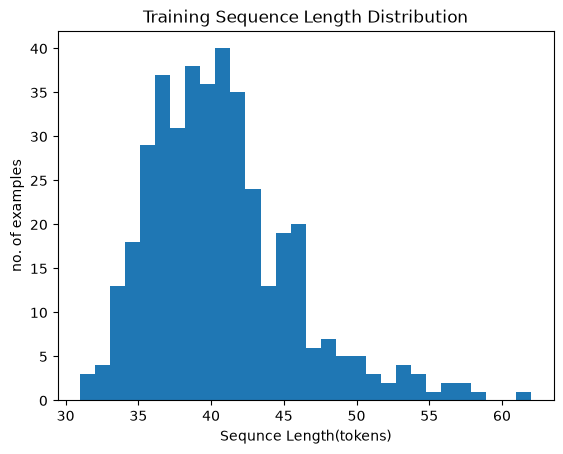

In [ ]:
# Plotting sequence-length distribution
import matplotlib.pyplot as plt

lengths = []
for x in training_data:
    data = analyze_example(x, tokenizer)
    lengths.append(data['num_tokens'])

plt.hist(lengths, bins=35)
plt.xlabel('Sequnce Length(tokens)')
plt.ylabel('no. of examples')
plt.title('Training Sequence Length Distribution')